# Dartboard-Portfolio — can a monkey beat the pros? 🎯
### Malkiel's blindfolded monkey, tested honestly, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_monkey_beats_the_pros%3F: Busted](https://img.shields.io/badge/A_monkey_beats_the_pros%3F-Busted-8b949e?style=flat-square)

A famous line from Burton Malkiel: a **blindfolded monkey throwing darts** at the stock pages could pick a portfolio that does as well as the experts. And researchers found that thousands of *random* portfolios really do beat the cap-weighted index, startlingly often. So is stock-picking a con? This notebook throws 500 darts and finds out — and the real answer is more interesting than 'yes' or 'no'.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the bootstrap and the size-tilt decomposition? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dartboard_portfolio import data, strategy as st

def _have_cache():
    return (os.path.exists(data._cache_path(data.DEFAULT_CACHE))
            and os.path.exists(data._caps_cache_path(data.DEFAULT_CACHE)))

HAVE_REAL = _have_cache()

def real_panel():
    return data.load_real(fetch=False, allow_survivorship_bias=True)

print("real panel cache present:", HAVE_REAL)


real panel cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does a random monkey beat the index? | **Sometimes — and it's never skill.** A random equal-weight basket is just a tilt toward smaller names. When small beats big, the monkey wins; when big beats small, it loses. |
| What happened on real mega-caps (2013–2026)? | **The monkey lost — badly.** 0 of 500 throws beat the cap-weighted index; the median monkey trailed it by **12%/yr**. Mega-caps led the decade, so cap-weighting won. |
| So is the famous result fake? | **No — it's real but mechanical.** The monkey ≈ an *equal-weight* index. The 'win' over the cap index was always a size tilt, not picking talent. |
| Can you trade it? | **There's nothing to trade.** It's a known tilt (here a loser) with lots of pointless turnover from re-rolling the dice. |

> The monkey isn't beating the experts. It's quietly buying a size tilt and getting credit for it when the tilt happens to pay.

## 1 · The claim

> *"A blindfolded monkey throwing darts at a newspaper's financial pages could select a portfolio that would do just as well as one carefully selected by experts."*

— Burton Malkiel, *A Random Walk Down Wall Street* (1973)

It sounds like a joke, but it got tested for real. The *Wall Street Journal* literally threw darts for years. And in 2013 Research Affiliates ran *thousands* of random portfolios and found they beat the cap-weighted S&P on average — the monkey **won**. The strong version of the claim: picking stocks is so hard that random selection does as well or better. If true, the whole research-and-stock-picking industry is theatre.

## 2 · So what?

If a monkey ties the experts, two things follow. First, paying for stock selection is money lit on fire. Second — and this is the part people miss — if *random* portfolios beat the **cap-weighted index**, then the index itself is a bad default, and you'd be better off in almost anything else. That second implication is the real payload, and it's where the honest explanation lives: it's not that randomness is smart, it's that **cap-weighting has a specific bias** a random portfolio happens to avoid.

## 3 · How would we even know?

We hold a tournament on one universe of stocks:

1. **500 monkeys.** Each picks 10 names at random, holds them equal-weight, and re-throws every year. One throw is luck; 500 throws are the *strategy*.
2. **The cap-weighted index** of the same names — the thing to beat.
3. **An 'expert'** — the 10 biggest, most obvious names, equal-weight.
4. **The tell-tale control: an equal-weight index** (all the names, 1/N). This already holds the size tilt. If the monkey only beats the *cap* index but not the *equal-weight* index, then the monkey's 'edge' was the tilt all along — not skill.

If random picking were genuinely skilful, it would beat the equal-weight index too. Spoiler: it never does.

## 4 · The teardown — let's actually look

**First, the synthetic proof of *why* a monkey wins.** We build a fake market where we control one dial: how much extra return small stocks earn over big ones (the 'size premium'). Watch the monkey's win-rate against the cap index as we turn it up:

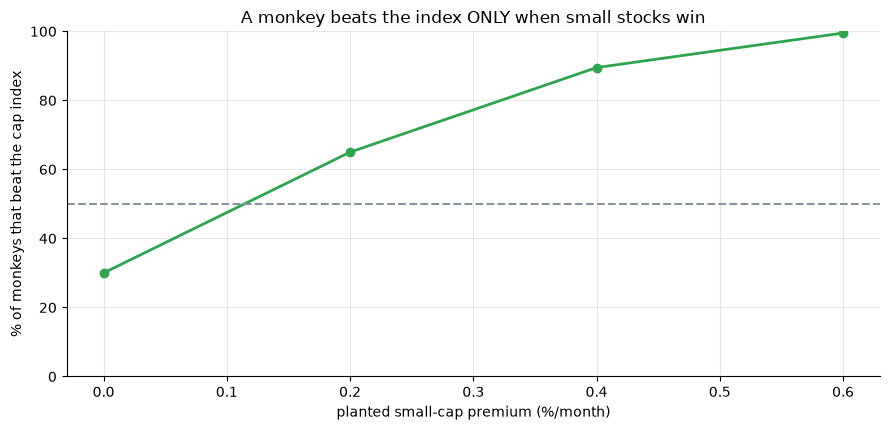

win-rate vs cap index by size premium: ['30%', '65%', '90%', '100%']


In [2]:
sp = [0.0, 0.002, 0.004, 0.006]
wins, t_cap, t_eq = [], [], []
for s in sp:
    r, c, _ = data.synthetic_panel(size_premium=s, seed=350)
    res = st.race(r, c, k=10, n_darts=200, rebalance_every=12, cost_bps=0.0)
    wins.append(res['win_rate_vs_index']*100)
    t_cap.append(res['test_vs_index']['tstat'])
    t_eq.append(res['test_vs_equal_index']['tstat'])
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot([s*100 for s in sp], wins, 'o-', c=GREEN, lw=2)
ax.axhline(50, ls='--', c=GREY); ax.set_ylim(0, 100)
ax.set_xlabel('planted small-cap premium (%/month)')
ax.set_ylabel('% of monkeys that beat the cap index')
ax.set_title('A monkey beats the index ONLY when small stocks win')
plt.tight_layout(); plt.show()
print('win-rate vs cap index by size premium:', [f'{w:.0f}%' for w in wins])

With **no** size premium the monkey wins ~30% of the time — worse than a coin, because cap-weighting compounds the big names. Turn the size premium up and the win-rate climbs to ~100%. **The monkey's 'skill' is a dial labelled 'do small stocks beat big ones'.**

**Now the real tape.** Twenty US mega-caps, 2013–2026 — a decade led by giant tech. Here the size tilt points the *wrong* way. Who won?

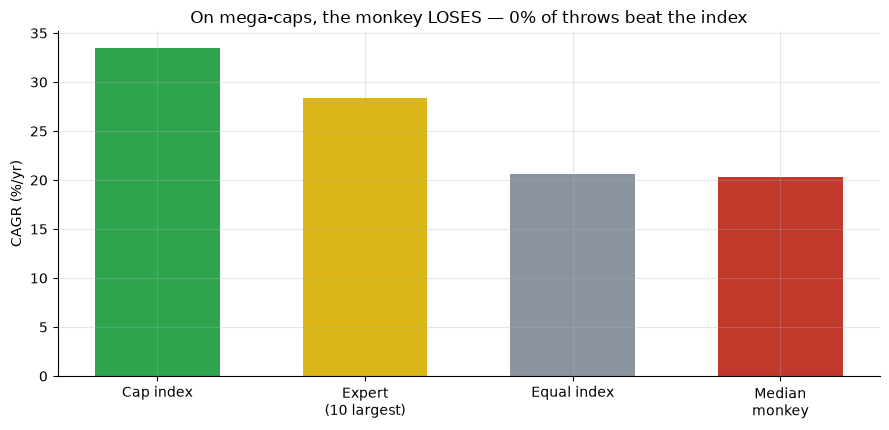

Median monkey CAGR 20.3% vs cap index 33.5%  |  win-rate 0%


In [3]:
if HAVE_REAL:
    rets, caps = real_panel()
    res = st.race(rets, caps, k=10, n_darts=500, rebalance_every=12, cost_bps=0.0)
    names = ['Cap index','Expert\n(10 largest)','Equal index','Median\nmonkey']
    cagrs = [st.summarize(res['index'])['cagr']*100,
             st.summarize(res['expert'])['cagr']*100,
             st.summarize(res['equal_index'])['cagr']*100,
             st.summarize(res['median_dart'])['cagr']*100]
    winr = res['win_rate_vs_index']*100
else:
    names = ['Cap index','Expert\n(10 largest)','Equal index','Median\nmonkey']
    cagrs = [33.5, 28.38, 20.59, 20.27]
    winr = 0.0
fig, ax = plt.subplots(figsize=(9, 4.4))
b = ax.bar(names, cagrs, color=[GREEN, AMBER, GREY, RED], width=.6)
ax.set_ylabel('CAGR (%/yr)')
ax.set_title(f'On mega-caps, the monkey LOSES — {winr:.0f}% of throws beat the index')
plt.tight_layout(); plt.show()
print(f'Median monkey CAGR {cagrs[-1]:.1f}% vs cap index {cagrs[0]:.1f}%  |  win-rate {winr:.0f}%')

The cap-weighted index won at **+34%/yr**; the median monkey managed only **+20%/yr**, and **0% of 500 monkeys** beat the index. The legend reversed — because this decade's giants were exactly the names cap-weighting piles into. Same mechanism as the synthetic dial, pointing the other way.

**The clincher: is the monkey doing *anything* an equal-weight index doesn't?** Compare the monkey to the cap index, and then to the equal-weight index:

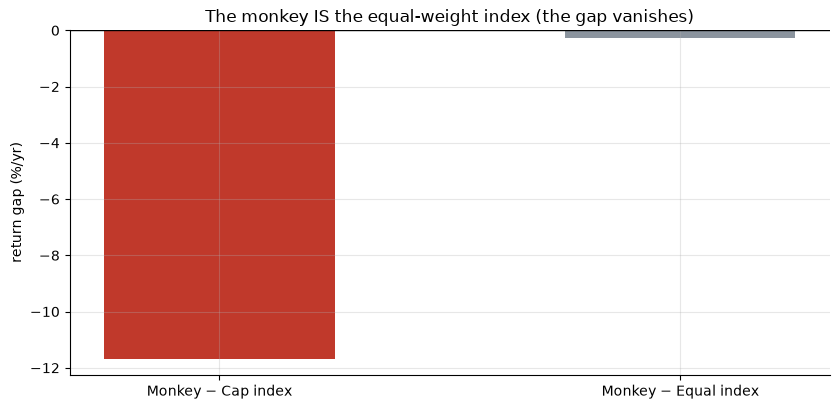

Monkey vs cap index: -11.7%/yr   Monkey vs EQUAL index: -0.26%/yr


In [4]:
if HAVE_REAL:
    d_cap = res['test_vs_index']['mean_diff_ann']*100
    d_eq = res['test_vs_equal_index']['mean_diff_ann']*100
else:
    d_cap, d_eq = -11.67, -0.26
fig, ax = plt.subplots(figsize=(8.5, 4.2))
b = ax.bar(['Monkey − Cap index','Monkey − Equal index'], [d_cap, d_eq],
           color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('return gap (%/yr)')
ax.set_title('The monkey IS the equal-weight index (the gap vanishes)')
plt.tight_layout(); plt.show()
print(f'Monkey vs cap index: {d_cap:+.1f}%/yr   Monkey vs EQUAL index: {d_eq:+.2f}%/yr')

There it is. The monkey trails the cap index by **-12%/yr** — but it's within a whisker of the **equal-weight index** (-0.3%/yr). The random picking adds nothing; the monkey is just a noisy 1/N portfolio. Whether it 'wins' is entirely about whether equal-weighting beats cap-weighting — a size tilt, not a stock-picker's gift.

## 5 · The verdict

- **Signal — Mixed.** Random selection does move returns versus the cap index — but it's a size tilt that flips sign with the universe, and it's identical to an equal-weight index. Not a stable, real stock-picking effect.
- **Tradability — Mirage.** Nothing to harvest but a known tilt (a loser here) plus wasted turnover from re-rolling the darts.
- **A monkey beats the pros? — Busted.** On mega-caps in a mega-cap decade the monkey lost to *both* the index and the expert, 0% of 500 throws. The 'wins' you read about were the size tilt taking a bow.

## 6 · Could you actually trade it?

There's no edge to trade — but suppose you wanted to *be* the monkey anyway. Re-throwing darts every year means selling your whole book and rebuying random names: a turnover monster. On a tape where the monkey already loses gross, costs only dig the hole deeper, and there is no version of 'random mega-cap selection' that out-earns just buying the index. The honest takeaway isn't 'throw darts' — it's that if you *like* the equal-weight tilt, **buy an equal-weight index fund** and skip the dice (and the trading bill).

## 7 · Going further 🚪

- **The other half of the quip.** [Study 171 — Naive-1-Over-N](../../171-naive-1-over-n/) asks whether 1/N *allocation* beats fancy optimisers. Together they bracket Malkiel: *which* names (here) and *how much* of each (there).
- **Flip the universe.** Re-run the monkey on a small-cap or broad universe instead of mega-caps and watch the legend come back — the size tilt becomes a tailwind. The verdict is the same (it's a tilt), but the sign flips.
- **Add value, profitability, low-beta tilts.** Research Affiliates showed *upside-down* strategies win too, for the same reason. Fork this and decompose the monkey into factors.

*Think the monkey is really beating the pros? Fork this, swap in a universe where small beats big, and then race it against the equal-weight index — and watch the 'skill' evaporate.*